In [1]:
from skymap import io
from skymap import plots as plots
from skymap import healmap as map
from skymap import Beam
import numpy as np 
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from astropy.io import fits
import astropy.units as u
from datetime import datetime

### Source cuts

- Scan 5 and 6: peakscan (elevation scans) 3C353 (13:02)
    - 10 deg offset on the peak
- Scan 7 and 8: peakscan (azimuth scan) of 3C353 (13:06)
    - 10 deg offset


In [2]:


datadir : Path = "/Users/akshatha.vydula/packages_310/skymap/data_310/TGBT25B_614_01"

#time of observation

start_time = datetime(2026, 1, 16, 18, 4)
end_time = datetime(2026, 1, 16, 18, 6)

source_cut_file = datadir + "/310/3c353_source_cut_2026_01_16.hdf5"

print(source_cut_file)





/Users/akshatha.vydula/packages_310/skymap/data_310/TGBT25B_614_01/310/3c353_source_cut_2026_01_16.hdf5


In [3]:

scan_obs = io.read_obs_hdf5(source_cut_file)



In [3]:
pointing_data = io.get_pointing_data(datadir+'/Antenna/', start_time, end_time)

Pointing: 2 file(s) (core by filename=2, spill_before=0, spill_after=0) for 2026-01-16 18:04:00 .. 2026-01-16 18:06:00 UTC
  start_utc is on or after the first core file's name (minute floor); backward spill not needed
  ANTPOSGR rows: 702 combined -> 702 with 61056.752778 <= DMJD <= 61056.754167


In [13]:
hdul = fits.open(datadir+'/Antenna/2026_01_16_17:49:32.fits')
hdul.info()

Filename: /Users/akshatha.vydula/packages_310/skymap/data_310/TGBT25B_614_01/Antenna/2026_01_16_17:49:32.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     112   ()      
  1  BEAM_OFFSETS    1 BinTableHDU     24   2R x 5C   [32A, 1D, 1D, 1J, 1J]   
  2  ANTPOSGR      1 BinTableHDU     57   0R x 16C   [1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D]   
  3  DYN_POINT     1 BinTableHDU     21   1R x 4C   [1D, 1D, 1D, 1D]   
  4  DYN_FOCUS     1 BinTableHDU     15   1R x 2C   [1D, 1D]   


In [19]:
hdul['DYN_POINT'].data

FITS_rec([(61056.59189931, 0., 0., 0.)],
         dtype=(numpy.record, [('DMJD', '>f8'), ('DYN_AZ1', '>f8'), ('DYN_AZ2', '>f8'), ('DYN_EL', '>f8')]))

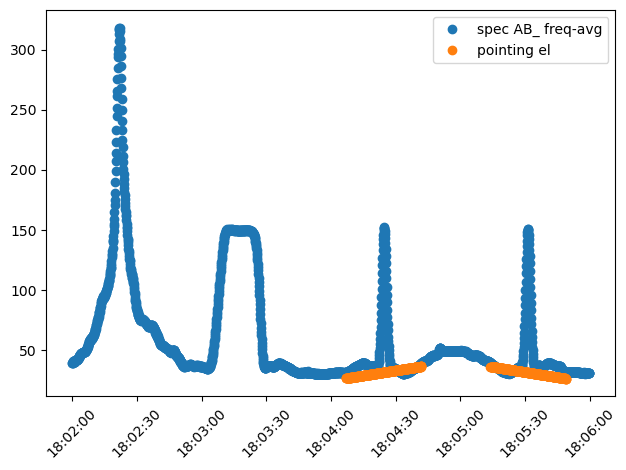

In [6]:
from astropy.time import Time

# If pointing_data.dmjd is MJD (UTC), you must specify the format explicitly
# (otherwise astropy can't infer it from plain floats).
t_point_utc = Time(pointing_data.dmjd, format="mjd", scale="utc").to_datetime()

# scan_obs.time from io.read_obs_hdf5 is already datetime-like (UTC-naive), so you can plot directly.
# If you want to force astropy conversion, use: Time(scan_obs.time, scale="utc").to_datetime()
t_spec_utc = np.asarray(scan_obs.time)

plt.figure()

plt.plot(t_spec_utc, np.nanmean(scan_obs.calibrated_spec.AB_, axis=1), "o", label="spec AB_ freq-avg")
plt.plot(t_point_utc, pointing_data.el, "o", label="pointing el")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


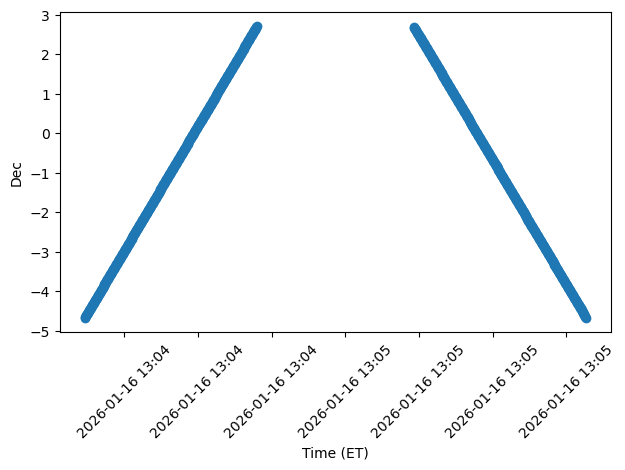

In [7]:
from skymap.utils import mjd_utc_to_et
import matplotlib.dates as mdates

# Convert MJD (UTC) to Eastern Time for the x-axis
t_et = mjd_utc_to_et(pointing_data.dmjd)

plt.figure()
plt.plot(t_et, pointing_data.dec, 'o')
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz=t_et.flat[0].tzinfo))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)
plt.xlabel('Time (ET)')
plt.ylabel('Dec')
plt.tight_layout()
plt.show()

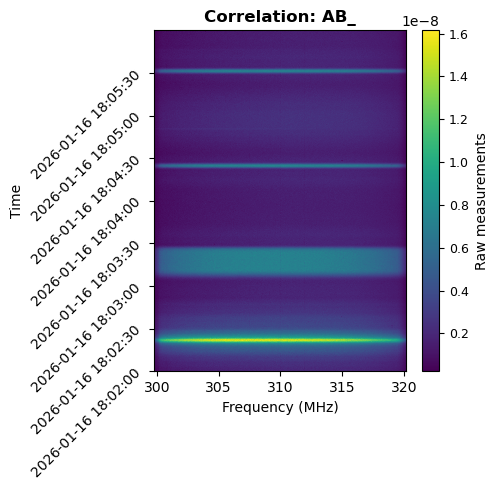

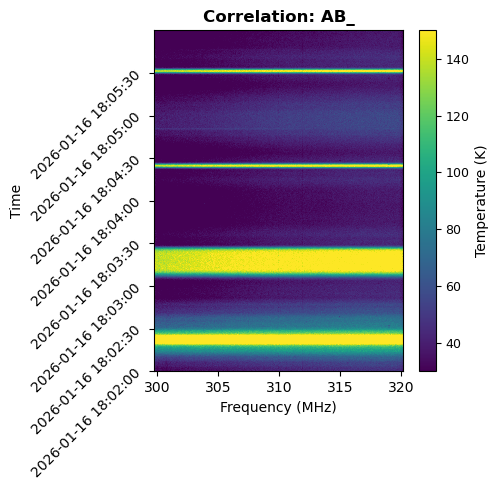

In [8]:
plots.plot_waterfall(scan_obs, data_type="magnitude", attribute="AB_");
plots.plot_waterfall(scan_obs, data_type="magnitude", attribute="AB_", calibrated=True, clim=(30, 150));

In [9]:
from astropy.time import Time

print("rough timing error in matching")
cadence_spec = (Time(scan_obs.time[2], scale="utc") - Time(scan_obs.time[1], scale="utc")).to(u.s)
cadence_point = ((pointing_data.dmjd[2] - pointing_data.dmjd[1]) * u.day).to(u.s)
print("cadence of spectra data:", cadence_spec)
print("cadence of pointing data:", cadence_point)


rough timing error in matching
cadence of spectra data: 0.10000000000545128 s
cadence of pointing data: 0.10000008624047041 s


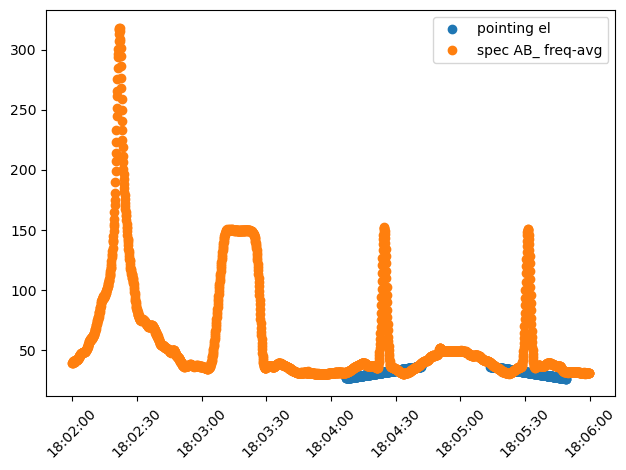

In [10]:
from astropy.time import Time

# If pointing_data.dmjd is MJD (UTC), you must specify the format explicitly
t_point_utc = Time(pointing_data.dmjd, format="mjd", scale="utc").to_datetime()

# scan_obs.time from io.read_obs_hdf5 is already datetime-like (UTC-naive)
t_spec_utc = np.asarray(scan_obs.time)

plt.figure()
plt.plot(t_point_utc, pointing_data.el, "o", label="pointing el")
plt.plot(t_spec_utc, np.nanmean(scan_obs.calibrated_spec.AB_, axis=1), "o", label="spec AB_ freq-avg")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
scan_obs_pointing = io.match_data_and_pointing(scan_obs, pointing_data)

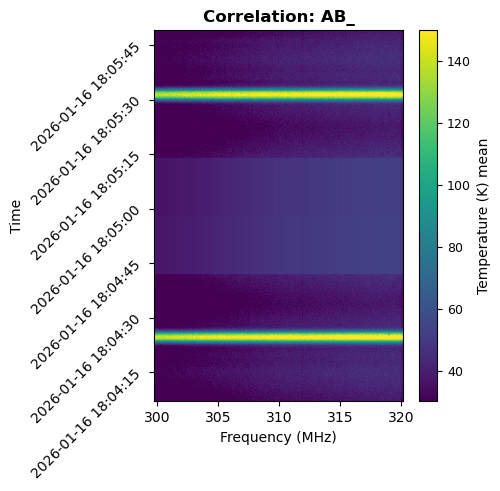

In [12]:
plots.plot_waterfall(scan_obs_pointing, spec_attr="calibrated_spec_mean", attribute="AB_", calibrated=True, clim=(30, 150));

In [13]:
scan_obs.calibrated_spec.AA_.shape, pointing_data.az.shape, scan_obs_pointing.time.shape, scan_obs.time.shape

((2400, 256), (702,), (702,), (2400,))

In [14]:
#david's calculation
# pointing offset: 0.06945 deg in ele 0.01011 in az 

off = io.get_pointing_offset(scan_obs_pointing, "3C353")
off["az_offset"], off["el_offset"]

(0.010459063534767665, 0.14641676634524714)

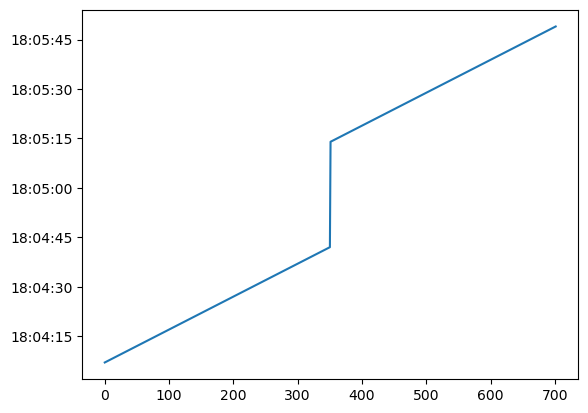

In [15]:
plt.plot(scan_obs_pointing.time)

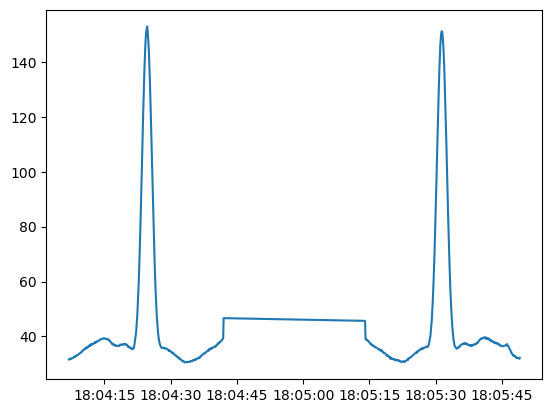

In [16]:
plt.plot(scan_obs_pointing.time, scan_obs_pointing.calibrated_spec_mean.AB_.mean(axis=1))
src_ra, src_dec = Beam.get_source_radec("3C353")


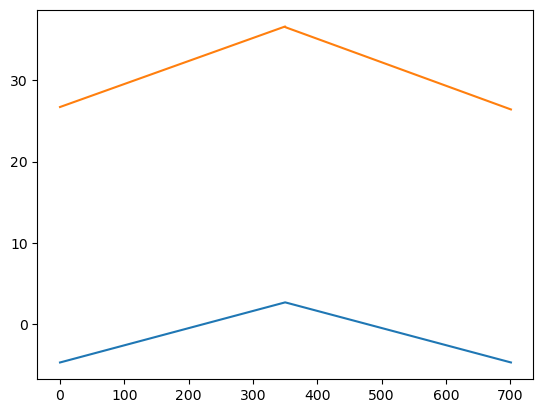

In [17]:
plt.plot(scan_obs_pointing.dec);
plt.plot(scan_obs_pointing.el)

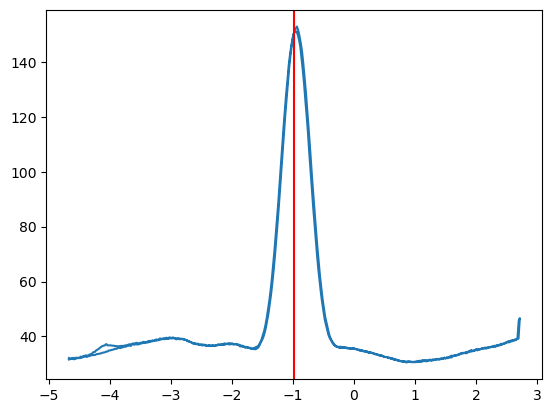

In [18]:
plt.plot(scan_obs_pointing.dec, scan_obs_pointing.calibrated_spec_mean.AB_.mean(axis=1))
plt.axvline(src_dec, color='red')

/Users/akshatha.vydula/packages_310/skymap/src/skymap/plots.py:799: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


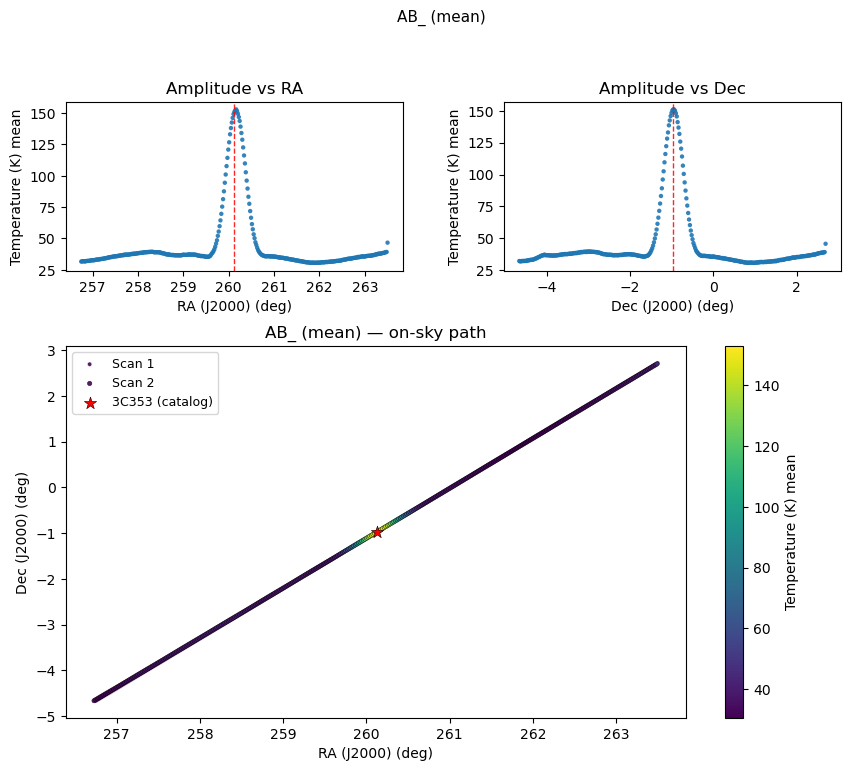

In [19]:
plots.plot_freq_avg_vs_pointing(
    scan_obs_pointing,
    source_name="3C353",
    calibrated=True,
    attribute="AB_",
)


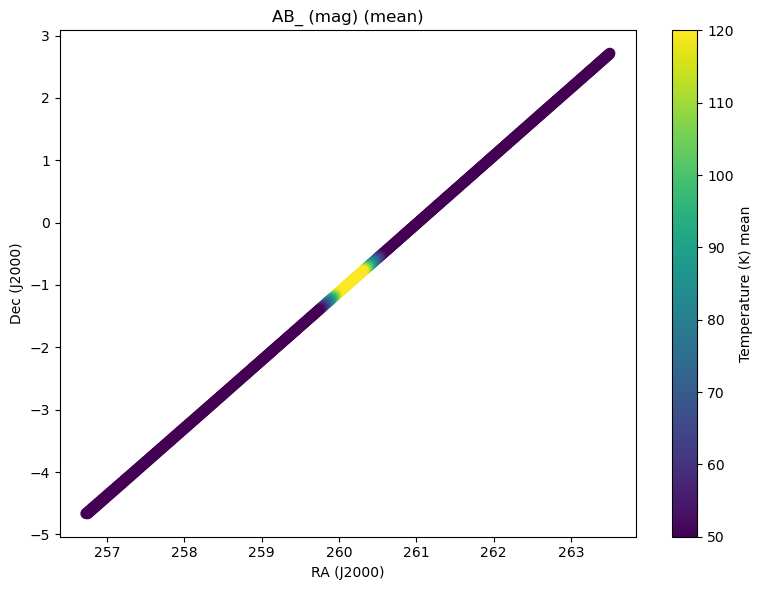

In [20]:
plots.plot_waterfall_with_pointing(scan_obs_pointing, calibrated=True, attribute="AB_", 
RADEC_map=True, freq_avg=True, use_std=False, size=50, clim=(50, 120));


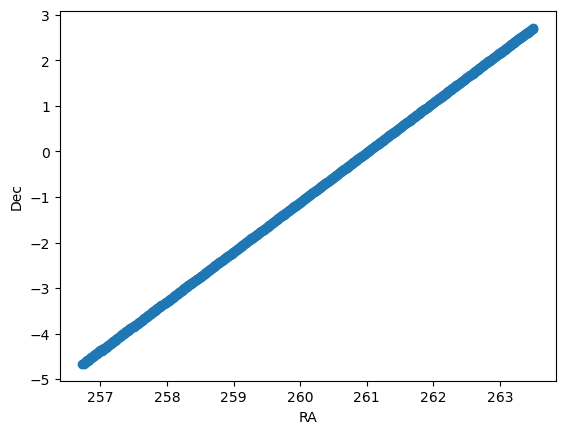

In [21]:
plt.plot(scan_obs_pointing.ra, scan_obs_pointing.dec, 'o')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.show()



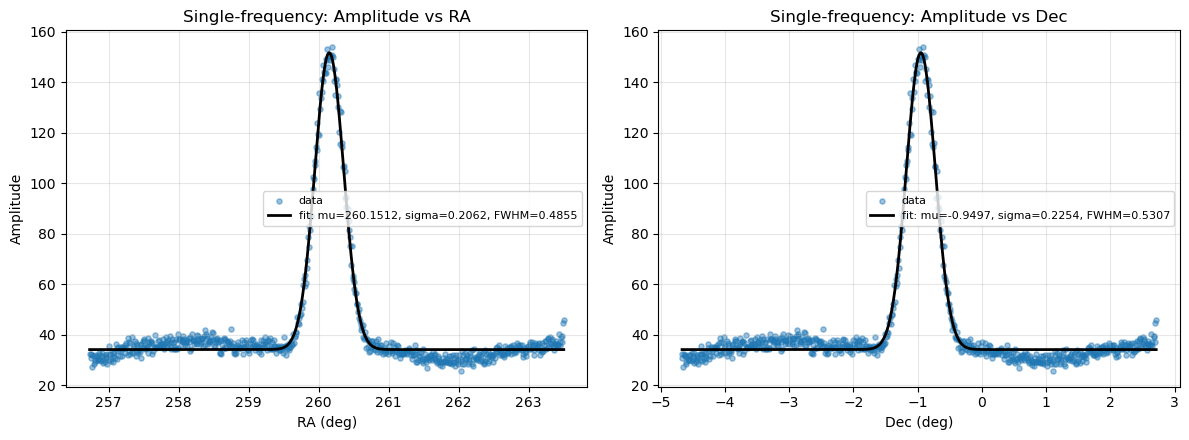

Single-frequency RA fit: {'A': 117.50521468462601, 'mu_deg': 260.151233144375, 'sigma_deg': 0.2061927608809805, 'FWHM_deg': 0.4855468464628063, 'baseline': 34.11108046389478, 'covariance': array([[ 3.77527404e-01, -2.04348998e-07, -4.04573595e-04,
        -1.12225408e-02],
       [-2.04348998e-07,  1.51775988e-06,  1.59741836e-09,
        -1.61952930e-08],
       [-4.04573595e-04,  1.59741836e-09,  1.61572015e-06,
        -3.93959349e-05],
       [-1.12225408e-02, -1.61952930e-08, -3.93959349e-05,
         1.58725560e-02]])}
Single-frequency Dec fit: {'A': 117.50032115649155, 'mu_deg': -0.9497231970297653, 'sigma_deg': 0.22538230787682534, 'FWHM_deg': 0.5307347763836852, 'baseline': 34.111000700851584, 'covariance': array([[ 3.78597237e-01, -1.28989507e-07, -4.43511935e-04,
        -1.12547451e-02],
       [-1.28989507e-07,  1.81858562e-06, -2.40392862e-10,
         2.19081894e-09],
       [-4.43511935e-04, -2.40392862e-10,  1.93607561e-06,
        -4.31851384e-05],
       [-1.12547451

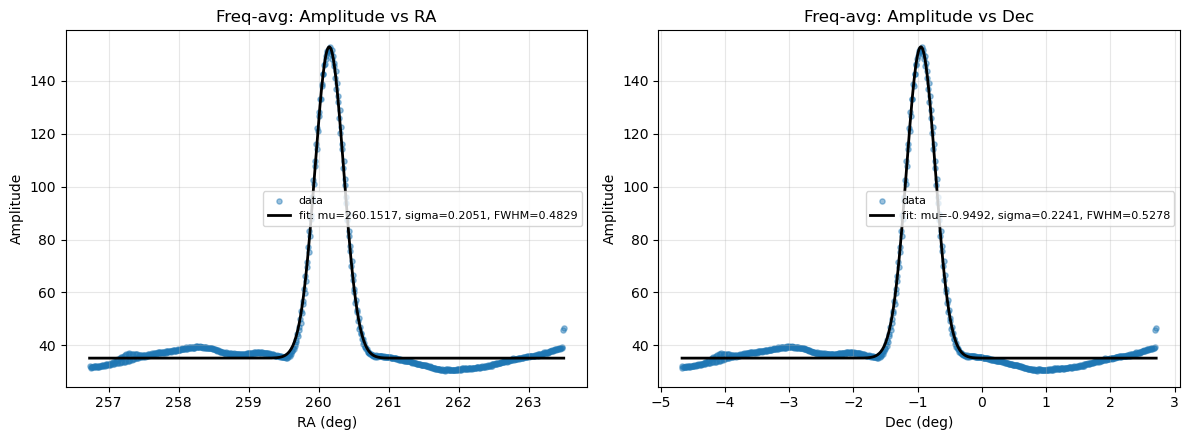

Freq-avg RA fit: {'A': 117.6160248839912, 'mu_deg': 260.15174367169294, 'sigma_deg': 0.20505951766942365, 'FWHM_deg': 0.48287826263233696, 'baseline': 35.19271091349066, 'covariance': array([[ 2.52430042e-01, -1.39492508e-07, -2.68932762e-04,
        -7.45569493e-03],
       [-1.39492508e-07,  1.00195973e-06,  1.05932656e-09,
        -1.06211709e-08],
       [-2.68932762e-04,  1.05932656e-09,  1.06620808e-06,
        -2.60044319e-05],
       [-7.45569493e-03, -1.06211709e-08, -2.60044319e-05,
         1.05449534e-02]])}
Freq-avg Dec fit: {'A': 117.613239976705, 'mu_deg': -0.9491615018574708, 'sigma_deg': 0.22413709102801113, 'FWHM_deg': 0.5278025147876871, 'baseline': 35.19271107500772, 'covariance': array([[ 2.53179322e-01, -8.55431584e-08, -2.94843826e-04,
        -7.47783752e-03],
       [-8.55431584e-08,  1.20059564e-06, -1.58985265e-10,
         1.42410165e-09],
       [-2.94843826e-04, -1.58985265e-10,  1.27765975e-06,
        -2.85070537e-05],
       [-7.47783752e-03,  1.4241016

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def gauss_with_baseline(x, A, mu, sigma, b):
    return b + A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def fit_axis_beam(x, y, x_name="x", ax=None):
    m = np.isfinite(x) & np.isfinite(y)
    x = np.asarray(x[m], dtype=float)
    y = np.asarray(y[m], dtype=float)
    if x.size < 5:
        raise ValueError(f"Not enough points to fit {x_name}")

    # Initial guesses
    b0 = np.nanpercentile(y, 20)
    A0 = max(np.nanmax(y) - b0, 1e-6)
    mu0 = x[np.nanargmax(y)]
    sigma0 = max(np.nanstd(x) / 3.0, 1e-3)

    p0 = [A0, mu0, sigma0, b0]
    bounds = ([0.0, np.nanmin(x), 1e-6, -np.inf],
              [np.inf, np.nanmax(x), np.inf, np.inf])

    popt, pcov = curve_fit(gauss_with_baseline, x, y, p0=p0, bounds=bounds, maxfev=20000)
    A, mu, sigma, b = popt
    fwhm = 2.0 * np.sqrt(2.0 * np.log(2.0)) * sigma

    xx = np.linspace(np.nanmin(x), np.nanmax(x), 600)
    yy = gauss_with_baseline(xx, *popt)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(x, y, s=14, alpha=0.45, label="data")
    ax.plot(xx, yy, "k-", lw=2, label=f"fit: mu={mu:.4f}, sigma={sigma:.4f}, FWHM={fwhm:.4f}")
    ax.set_xlabel(f"{x_name} (deg)")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    return {
        "A": float(A),
        "mu_deg": float(mu),
        "sigma_deg": float(sigma),
        "FWHM_deg": float(fwhm),
        "baseline": float(b),
        "covariance": pcov,
    }

# ----------------------------
# INPUTS
# ----------------------------
pol = "AB_"
source = "3C353"   # optional, only for plotting source RA/Dec
arr2d = scan_obs_pointing.calibrated_spec_mean.__getattribute__(pol)  # shape: (n_pointing, n_freq)

# ----------------------------
# 1) SINGLE-FREQUENCY amplitude
# ----------------------------
freq_idx = 100
amp_single = np.asarray(arr2d[:, freq_idx], dtype=float)

ra = np.asarray(scan_obs_pointing.ra, dtype=float)
dec = np.asarray(scan_obs_pointing.dec, dtype=float)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
fit_ra_single = fit_axis_beam(ra, amp_single, x_name="RA", ax=axs[0])
fit_dec_single = fit_axis_beam(dec, amp_single, x_name="Dec", ax=axs[1])
axs[0].set_title("Single-frequency: Amplitude vs RA")
axs[1].set_title("Single-frequency: Amplitude vs Dec")
plt.tight_layout()
plt.show()

print("Single-frequency RA fit:", fit_ra_single)
print("Single-frequency Dec fit:", fit_dec_single)

# ----------------------------
# 2) FREQUENCY-AVERAGED amplitude (like plot_freq_avg_vs_pointing)
# ----------------------------
amp_avg = np.nanmean(np.asarray(arr2d, dtype=float), axis=1)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
fit_ra_avg = fit_axis_beam(ra, amp_avg, x_name="RA", ax=axs[0])
fit_dec_avg = fit_axis_beam(dec, amp_avg, x_name="Dec", ax=axs[1])
axs[0].set_title("Freq-avg: Amplitude vs RA")
axs[1].set_title("Freq-avg: Amplitude vs Dec")
plt.tight_layout()
plt.show()

print("Freq-avg RA fit:", fit_ra_avg)
print("Freq-avg Dec fit:", fit_dec_avg)

In [23]:
Beam.save_beam_fit(fit_ra_single, Path("../outputs/beam_fit_params_ra.json"))

PosixPath('../outputs/beam_fit_params_ra.json')

In [24]:
fit_ra_single

{'A': 117.50521468462601,
 'mu_deg': 260.151233144375,
 'sigma_deg': 0.2061927608809805,
 'FWHM_deg': 0.4855468464628063,
 'baseline': 34.11108046389478,
 'covariance': array([[ 3.77527404e-01, -2.04348998e-07, -4.04573595e-04,
         -1.12225408e-02],
        [-2.04348998e-07,  1.51775988e-06,  1.59741836e-09,
         -1.61952930e-08],
        [-4.04573595e-04,  1.59741836e-09,  1.61572015e-06,
         -3.93959349e-05],
        [-1.12225408e-02, -1.61952930e-08, -3.93959349e-05,
          1.58725560e-02]])}